<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Normalization Techniques**


Estimated time needed: **30** minutes


In this lab, you will focus on data normalization. This includes identifying compensation-related columns, applying normalization techniques, and visualizing the data distributions.


## Objectives


In this lab, you will perform the following:


- Identify duplicate rows and remove them.

- Check and handle missing values in key columns.

- Identify and normalize compensation-related columns.

- Visualize the effect of normalization techniques on data distributions.


-----


## Hands on Lab


#### Step 1: Install and Import Libraries


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

### Step 2: Load the Dataset into a DataFrame


We use the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.


The functions below will download the dataset into your browser:


In [2]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)

# Display the first few rows to check if data is loaded correctly
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

In [ ]:
#df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")

### Section 1: Handling Duplicates
##### Task 1: Identify and remove duplicate rows.


In [3]:
## Write your code here
# i have to identify and remove duplicate rows from the dataframe  
duplicate_rows = df[df.duplicated()]
print("Duplicate rows:")
print(duplicate_rows)
df_no_duplicates = df.drop_duplicates()
print("Dataframe after removing duplicates:")
df = df_no_duplicates
print(df.head())

Duplicate rows:
Empty DataFrame
Columns: [ResponseId, MainBranch, Age, Employment, RemoteWork, Check, CodingActivities, EdLevel, LearnCode, LearnCodeOnline, TechDoc, YearsCode, YearsCodePro, DevType, OrgSize, PurchaseInfluence, BuyNewTool, BuildvsBuy, TechEndorse, Country, Currency, CompTotal, LanguageHaveWorkedWith, LanguageWantToWorkWith, LanguageAdmired, DatabaseHaveWorkedWith, DatabaseWantToWorkWith, DatabaseAdmired, PlatformHaveWorkedWith, PlatformWantToWorkWith, PlatformAdmired, WebframeHaveWorkedWith, WebframeWantToWorkWith, WebframeAdmired, EmbeddedHaveWorkedWith, EmbeddedWantToWorkWith, EmbeddedAdmired, MiscTechHaveWorkedWith, MiscTechWantToWorkWith, MiscTechAdmired, ToolsTechHaveWorkedWith, ToolsTechWantToWorkWith, ToolsTechAdmired, NEWCollabToolsHaveWorkedWith, NEWCollabToolsWantToWorkWith, NEWCollabToolsAdmired, OpSysPersonal use, OpSysProfessional use, OfficeStackAsyncHaveWorkedWith, OfficeStackAsyncWantToWorkWith, OfficeStackAsyncAdmired, OfficeStackSyncHaveWorkedWith, Of

### Section 2: Handling Missing Values
##### Task 2: Identify missing values in `CodingActivities`.


In [4]:
## Write your code here
# i have to identify the missing values in column 'CodingActivities'
missing_coding_activities = df['CodingActivities'].isnull().sum()
print(f"Missing values in 'CodingActivities' column: {missing_coding_activities}")


Missing values in 'CodingActivities' column: 10971


##### Task 3: Impute missing values in CodingActivities with forward-fill.


In [7]:
## Write your code here
# i have to impute the missing values in the 'CodingActivities' with forward fill method
df['CodingActivities'] = df['CodingActivities'].ffill()

missing_coding_activities = df['CodingActivities'].isnull().sum()
print(f"Missing values in 'CodingActivities' column: {missing_coding_activities}")

Missing values in 'CodingActivities' column: 0


**Note**:  Before normalizing ConvertedCompYearly, ensure that any missing values (NaN) in this column are handled appropriately. You can choose to either drop the rows containing NaN or replace the missing values with a suitable statistic (e.g., median or mean).


In [11]:
# i have to find missing values in the 'ConvertedCompYearly' column
missing_converted_comp_yearly = df['ConvertedCompYearly'].isnull().sum()
print(f"Missing values in 'ConvertedCompYearly' column: {missing_converted_comp_yearly}")
# i have to replace the missing values with the mean of the column
mean_converted_comp_yearly = df['ConvertedCompYearly'].mean()
df['ConvertedCompYearly'] = df['ConvertedCompYearly'].fillna(mean_converted_comp_yearly)
missing_converted_comp_yearly = df['ConvertedCompYearly'].isnull().sum()
print(f"Missing values in 'ConvertedCompYearly' column after imputation: {missing_converted_comp_yearly}")

# I have to apply the same as above to the column 'CompTotal'
missing_comp_total = df['CompTotal'].isnull().sum()
print(f"Missing values in 'CompTotal' column: {missing_comp_total}")
mean_comp_total = df['CompTotal'].mean()
df['CompTotal'] = df['CompTotal'].fillna(mean_comp_total)
missing_comp_total = df['CompTotal'].isnull().sum()
print(f"Missing values in 'CompTotal' column after imputation: {missing_comp_total}")



Missing values in 'ConvertedCompYearly' column: 0
Missing values in 'ConvertedCompYearly' column after imputation: 0
Missing values in 'CompTotal' column: 31697
Missing values in 'CompTotal' column after imputation: 0


### Section 3: Normalizing Compensation Data
##### Task 4: Identify compensation-related columns, such as ConvertedCompYearly.
Normalization is commonly applied to compensation data to bring values within a comparable range. Here, you’ll identify ConvertedCompYearly or similar columns, which contain compensation information. This column will be used in the subsequent tasks for normalization.


In [12]:
## Write your code here
compensation_columns = [col for col in df.columns if any(keyword in col for keyword in ['salary', 'bonus', 'compensation', 'pay', 'income', 'wage', 'CompTotal', 'ConvertedCompYearly'])]
for col in compensation_columns:
    print(f"Distribution of {col}:")
    print(df[col].describe())
    print("\n")

Distribution of CompTotal:
count     6.543700e+04
mean     2.963841e+145
std      3.909176e+147
min       0.000000e+00
25%       1.030000e+05
50%       9.500000e+06
75%      2.963841e+145
max      1.000000e+150
Name: CompTotal, dtype: float64


Distribution of ConvertedCompYearly:
count    6.543700e+04
mean     8.615529e+04
std      1.117614e+05
min      1.000000e+00
25%      8.615529e+04
50%      8.615529e+04
75%      8.615529e+04
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64




##### Task 5: Normalize ConvertedCompYearly using Min-Max Scaling.
Min-Max Scaling brings all values in a column to a 0-1 range, making it useful for comparing data across different scales. Here, you will apply Min-Max normalization to the ConvertedCompYearly column, creating a new column ConvertedCompYearly_MinMax with normalized values.


In [13]:
## Write your code here
# i have to normalize the 'ConvertedCompYearly' column using min-max normalization and store the normalized values in a new column 'ConvertedCompYearly_MinMax'
min_converted_comp_yearly = df['ConvertedCompYearly'].min()
max_converted_comp_yearly = df['ConvertedCompYearly'].max()
df['ConvertedCompYearly_MinMax'] = (df['ConvertedCompYearly'] - min_converted_comp_yearly) / (max_converted_comp_yearly - min_converted_comp_yearly)
print(df[['ConvertedCompYearly', 'ConvertedCompYearly_MinMax']].head())

   ConvertedCompYearly  ConvertedCompYearly_MinMax
0         86155.287263                      0.0053
1         86155.287263                      0.0053
2         86155.287263                      0.0053
3         86155.287263                      0.0053
4         86155.287263                      0.0053


##### Task 6: Apply Z-score Normalization to `ConvertedCompYearly`.

Z-score normalization standardizes values by converting them to a distribution with a mean of 0 and a standard deviation of 1. This method is helpful for datasets with a Gaussian (normal) distribution. Here, you’ll calculate Z-scores for the ConvertedCompYearly column, saving the results in a new column ConvertedCompYearly_Zscore.


In [14]:
## Write your code here
# i have to apply z-score normalization to the 'ConvertedCompYearly' column and store the normalized values in a new column 'ConvertedCompYearly_ZScore'
mean_converted_comp_yearly = df['ConvertedCompYearly'].mean()
std_converted_comp_yearly = df['ConvertedCompYearly'].std()
df['ConvertedCompYearly_ZScore'] = (df['ConvertedCompYearly'] - mean_converted_comp_yearly) / std_converted_comp_yearly if std_converted_comp_yearly != 0 else 0
print(df[['ConvertedCompYearly', 'ConvertedCompYearly_ZScore']].head())

   ConvertedCompYearly  ConvertedCompYearly_ZScore
0         86155.287263                         0.0
1         86155.287263                         0.0
2         86155.287263                         0.0
3         86155.287263                         0.0
4         86155.287263                         0.0


### Section 4: Visualization of Normalized Data
##### Task 7: Visualize the distribution of `ConvertedCompYearly`, `ConvertedCompYearly_Normalized`, and `ConvertedCompYearly_Zscore`

Visualization helps you understand how normalization changes the data distribution. In this task, create histograms for the original ConvertedCompYearly, as well as its normalized versions (ConvertedCompYearly_MinMax and ConvertedCompYearly_Zscore). This will help you compare how each normalization technique affects the data range and distribution.


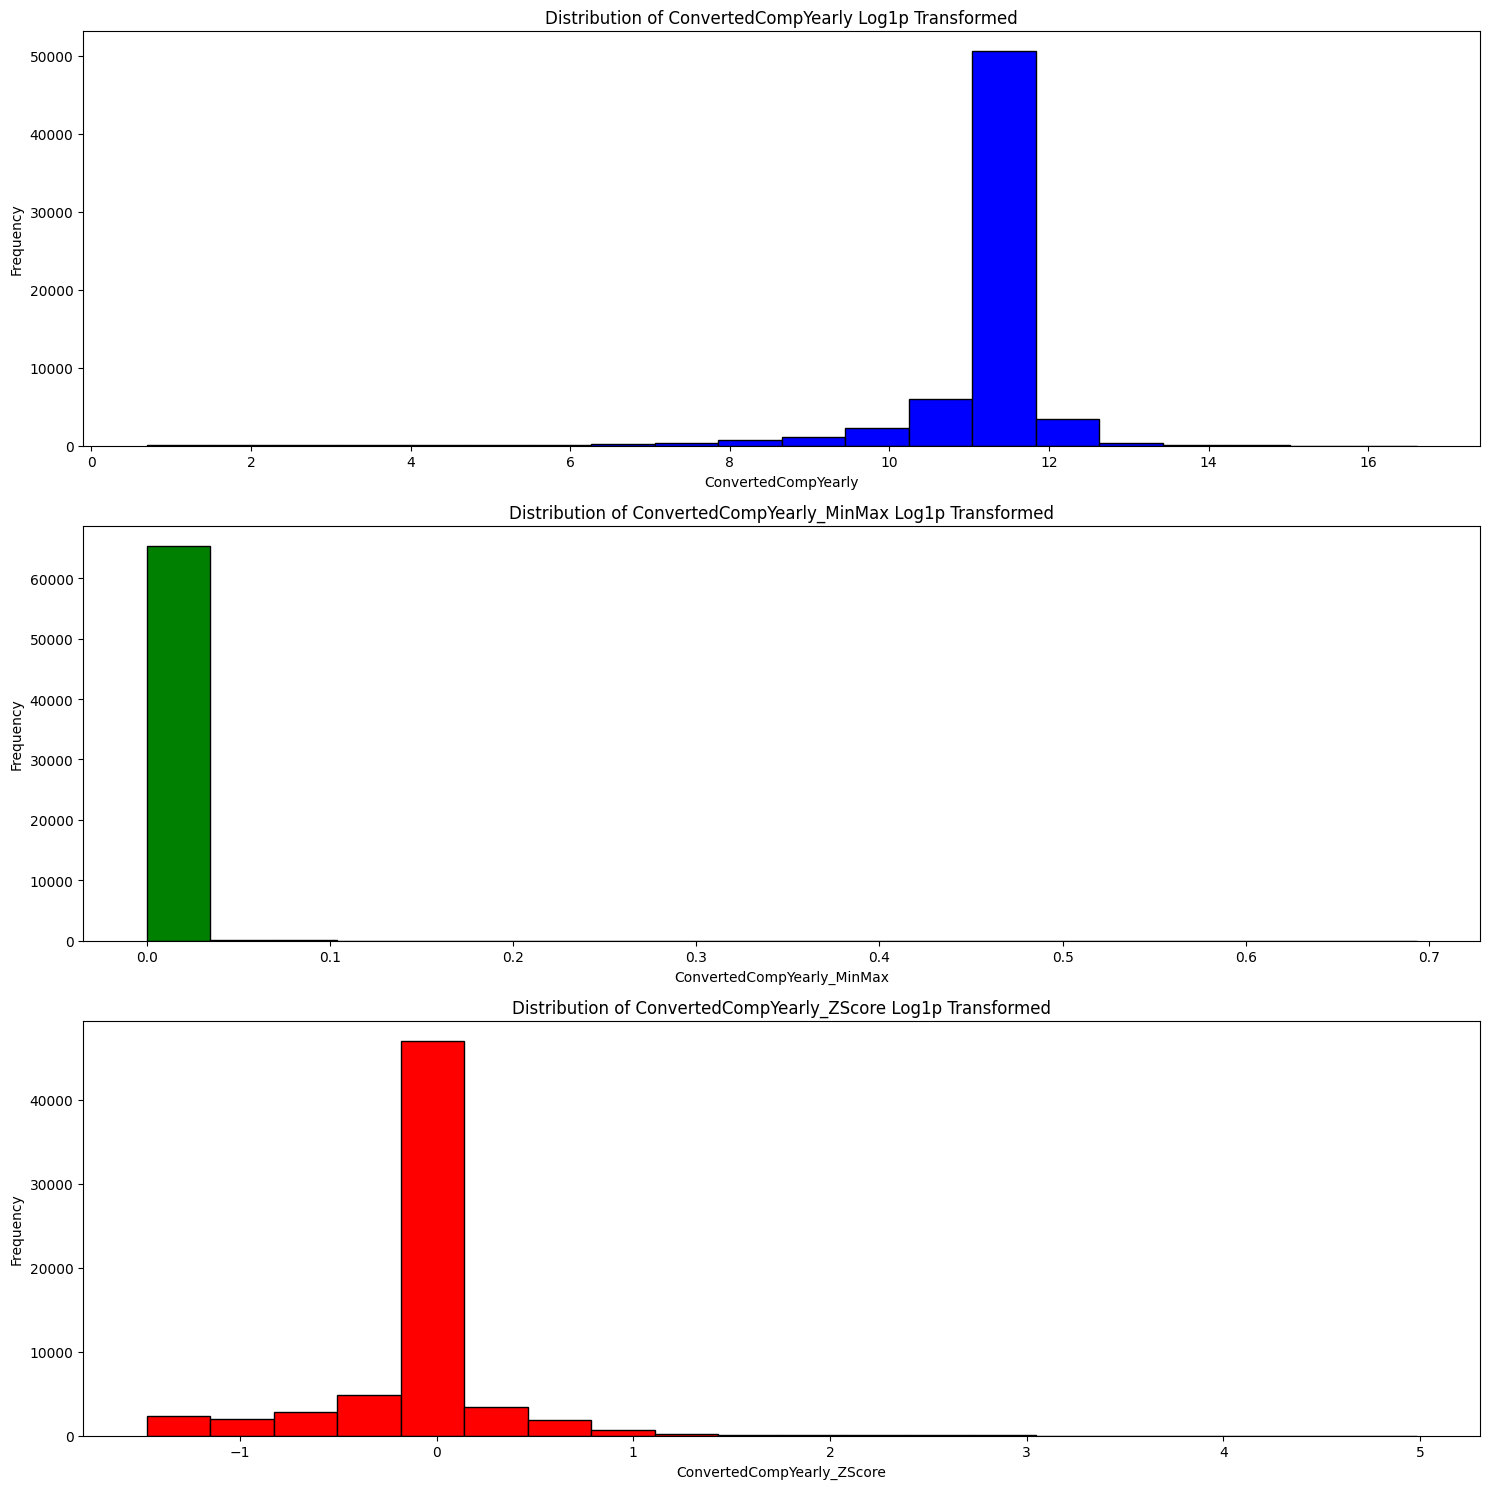

In [20]:
## Write your code here
# i have to create a histogram to visualize the distribution of the 'ConvertedCompYearly' column and for both new normalized columns
import numpy as np
plt.figure(figsize=(15, 15))
plt.subplot(3, 1, 1)
plt.hist(np.log1p(df['ConvertedCompYearly']), bins=20, color='blue', edgecolor='black')
plt.title('Distribution of ConvertedCompYearly Log1p Transformed')
plt.xlabel('ConvertedCompYearly')
plt.ylabel('Frequency')
plt.subplot(3, 1, 2)
plt.hist(np.log1p(df['ConvertedCompYearly_MinMax']), bins=20, color='green', edgecolor='black')
plt.title('Distribution of ConvertedCompYearly_MinMax Log1p Transformed')
plt.xlabel('ConvertedCompYearly_MinMax')
plt.ylabel('Frequency')
plt.subplot(3, 1, 3)
plt.hist(np.log1p(df['ConvertedCompYearly_ZScore']), bins=20, color='red', edgecolor='black')
plt.title('Distribution of ConvertedCompYearly_ZScore Log1p Transformed')
plt.xlabel('ConvertedCompYearly_ZScore')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Summary


In this lab, you practiced essential normalization techniques, including:

- Identifying and handling duplicate rows.

- Checking for and imputing missing values.

- Applying Min-Max scaling and Z-score normalization to compensation data.

- Visualizing the impact of normalization on data distribution.


Copyright © IBM Corporation. All rights reserved.
